In [ ]:
!git clone https://github.com/OPIM5512-prb23017/craigslist-furniture-price-model.git
%cd craigslist-furniture-price-model

Cloning into 'craigslist-furniture-price-model'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 121 (delta 31), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (121/121), 41.83 KiB | 4.65 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/craigslist-furniture-price-model


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

In [1]:
import os
import pandas as pd
import numpy as np
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("results/furniture_master.csv")

# Cleaning
df["price"] = df["price_raw"].replace('[\$,]', '', regex=True).astype(float)
df = df.dropna(subset=["price"])
df = df.fillna("unknown")

# Encode
for col in ["title", "location_raw"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

X = df[["title", "location_raw"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train
model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

run_id = datetime.now().strftime("%Y%m%d%H%M%S")

# Create folders
os.makedirs("results/metrics_history", exist_ok=True)
os.makedirs("results/importance", exist_ok=True)
os.makedirs("results/pdp", exist_ok=True)
os.makedirs("results/predictions", exist_ok=True)

# Save metrics
pd.DataFrame({
    "run_id":[run_id],
    "MAE":[mae],
    "RMSE":[rmse]
}).to_csv(f"results/metrics_history/{run_id}.csv", index=False)

# Importance
imp = permutation_importance(model, X_test, y_test)

imp_df = pd.DataFrame({
    "feature": X.columns,
    "importance": imp.importances_mean
})

imp_df.to_csv(f"results/importance/{run_id}.csv", index=False)

# PDP
fig, ax = plt.subplots(figsize=(8,4))
PartialDependenceDisplay.from_estimator(model, X_test, [0,1], ax=ax)
plt.savefig(f"results/pdp/{run_id}.png")

# Predictions
pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
}).to_csv(f"results/predictions/{run_id}.csv", index=False)

print("DONE ✅ Files created")

<>:18: SyntaxWarning: invalid escape sequence '\$'
<>:18: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_1252/4221607435.py:18: SyntaxWarning: invalid escape sequence '\$'
  df["price"] = df["price_raw"].replace('[\$,]', '', regex=True).astype(float)


FileNotFoundError: [Errno 2] No such file or directory: 'results/furniture_master.csv'

In [2]:
!git clone https://github.com/OPIM5512-prb23017/craigslist-furniture-price-model.git
%cd craigslist-furniture-price-model!git clone https://github.com/OPIM5512-prb23017/craigslist-furniture-price-model.git
%cd craigslist-furniture-price-model


Cloning into 'craigslist-furniture-price-model'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 121 (delta 31), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (121/121), 41.83 KiB | 2.46 MiB/s, done.
Resolving deltas: 100% (31/31), done.
[Errno 2] No such file or directory: 'craigslist-furniture-price-model!git clone https://github.com/OPIM5512-prb23017/craigslist-furniture-price-model.git'
/content
/content/craigslist-furniture-price-model


In [3]:
!ls results

furniture_master.csv  llm_features.csv	pdp	     raw_furniture_listings.csv
importance	      metrics_history	predictions  regex_features.csv


In [4]:
df = pd.read_csv("results/furniture_master.csv")

In [5]:
df["price"] = df["price_raw"].replace(r'[\$,]', '', regex=True).astype(float)

<>:18: SyntaxWarning: invalid escape sequence '\$'
<>:18: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_1252/4221607435.py:18: SyntaxWarning: invalid escape sequence '\$'
  df["price"] = df["price_raw"].replace('[\$,]', '', regex=True).astype(float)


DONE ✅ Files created


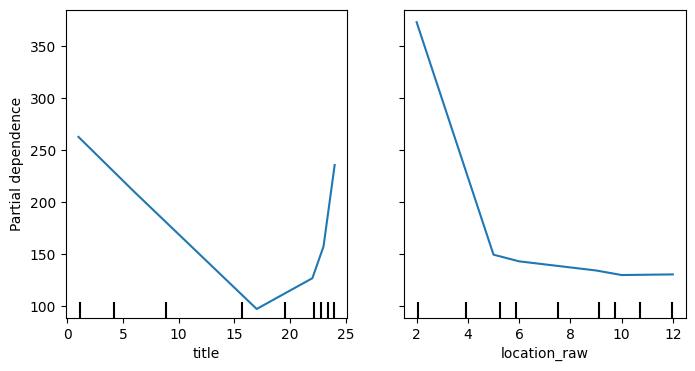

In [6]:
import os
import pandas as pd
import numpy as np
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("results/furniture_master.csv")

# Cleaning
df["price"] = df["price_raw"].replace('[\$,]', '', regex=True).astype(float)
df = df.dropna(subset=["price"])
df = df.fillna("unknown")

# Encode
for col in ["title", "location_raw"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

X = df[["title", "location_raw"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train
model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

run_id = datetime.now().strftime("%Y%m%d%H%M%S")

# Create folders
os.makedirs("results/metrics_history", exist_ok=True)
os.makedirs("results/importance", exist_ok=True)
os.makedirs("results/pdp", exist_ok=True)
os.makedirs("results/predictions", exist_ok=True)

# Save metrics
pd.DataFrame({
    "run_id":[run_id],
    "MAE":[mae],
    "RMSE":[rmse]
}).to_csv(f"results/metrics_history/{run_id}.csv", index=False)

# Importance
imp = permutation_importance(model, X_test, y_test)

imp_df = pd.DataFrame({
    "feature": X.columns,
    "importance": imp.importances_mean
})

imp_df.to_csv(f"results/importance/{run_id}.csv", index=False)

# PDP
fig, ax = plt.subplots(figsize=(8,4))
PartialDependenceDisplay.from_estimator(model, X_test, [0,1], ax=ax)
plt.savefig(f"results/pdp/{run_id}.png")

# Predictions
pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
}).to_csv(f"results/predictions/{run_id}.csv", index=False)

print("DONE ✅ Files created")

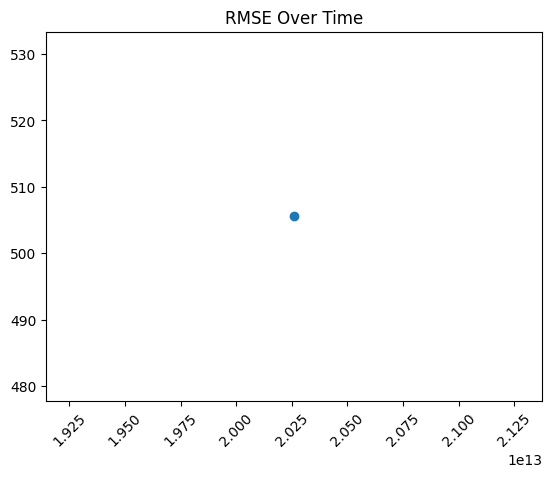

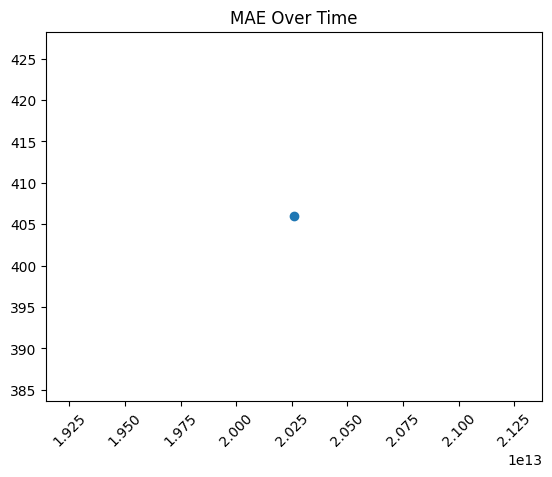

In [7]:
import glob

metrics_files = glob.glob("results/metrics_history/*.csv")

metrics_df = pd.concat([pd.read_csv(f) for f in metrics_files])
metrics_df = metrics_df.sort_values("run_id")

# RMSE
plt.figure()
plt.plot(metrics_df["run_id"], metrics_df["RMSE"], marker='o')
plt.xticks(rotation=45)
plt.title("RMSE Over Time")
plt.show()

# MAE
plt.figure()
plt.plot(metrics_df["run_id"], metrics_df["MAE"], marker='o')
plt.xticks(rotation=45)
plt.title("MAE Over Time")
plt.show()

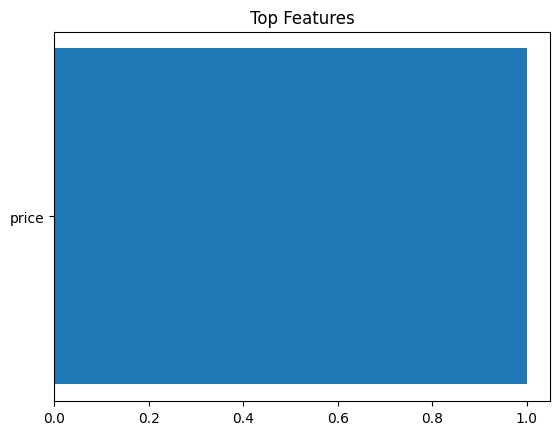

In [8]:
importance_files = glob.glob("results/importance/*.csv")

latest_importance = pd.read_csv(sorted(importance_files)[-1])

plt.figure()
plt.barh(latest_importance["feature"], latest_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()

In [9]:
df["title_length"] = df["title"].astype(str).apply(len)

X = df[["title_length", "location_raw"]]
y = df["price"]

In [10]:
!pip install pandas scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

In [11]:

!git clone https://github.com/OPIM5512-prb23017/craigslist-furniture-price-model.git
%cd craigslist-furniture-price-model

Cloning into 'craigslist-furniture-price-model'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 121 (delta 31), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (121/121), 41.83 KiB | 1.82 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/craigslist-furniture-price-model/craigslist-furniture-price-model


In [12]:
df = pd.read_csv("results/furniture_master.csv")
df.head()

,title,price_raw,location_raw,url,description,price,color,condition
0,Restoration Hardware couch / sofa,"$1,000",Brooklyn,https://newyork.craigslist.org/que/fuo/d/brook...,QR Code Link to This Post In like new conditio...,1000,NaN,NaN
1,Full Length Wall Mirror,$60,Astoria,https://newyork.craigslist.org/que/fuo/d/astor...,"QR Code Link to This Post Size : 64"" x 21"" Fin...",60,NaN,NaN
2,Italian Leather Navy Sofa - Bloomingdales,$750,Upper West Side,https://newyork.craigslist.org/mnh/fuo/d/new-y...,QR Code Link to This Post Deep blue - Barely u...,750,NaN,NaN
3,Silver floor lamp,$85,West Harrison,https://newyork.craigslist.org/wch/fuo/d/west-...,QR Code Link to This Post 5ft Silver floor lam...,85,NaN,NaN
4,Vintage Steelcase Tanker Desk,$550,Brooklyn,https://newyork.craigslist.org/que/fuo/d/brook...,QR Code Link to This Post Authentic vintage St...,550,NaN,NaN


In [13]:
# Fix price
df["price"] = df["price_raw"].replace(r'[\$,]', '', regex=True).astype(float)

# Remove nulls
df = df.dropna(subset=["price"])

# Fill missing
df = df.fillna("unknown")

In [14]:
# Create new features
df["title_length"] = df["title"].astype(str).apply(len)

# Encode location
le = LabelEncoder()
df["location_raw"] = le.fit_transform(df["location_raw"].astype(str))

# Final features
X = df[["title_length", "location_raw"]]
y = df["price"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [16]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

RandomForestRegressor()

In [18]:
y_pred = model.predict(X_test)

In [19]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 248.88658333333333
RMSE: 347.4719217505807


In [20]:
run_id = datetime.now().strftime("%Y%m%d%H%M%S")

os.makedirs("results/metrics_history", exist_ok=True)
os.makedirs("results/importance", exist_ok=True)
os.makedirs("results/pdp", exist_ok=True)
os.makedirs("results/predictions", exist_ok=True)

# Save metrics
pd.DataFrame({
    "run_id": [run_id],
    "MAE": [mae],
    "RMSE": [rmse]
}).to_csv(f"results/metrics_history/{run_id}.csv", index=False)

# Save predictions
pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
}).to_csv(f"results/predictions/{run_id}.csv", index=False)

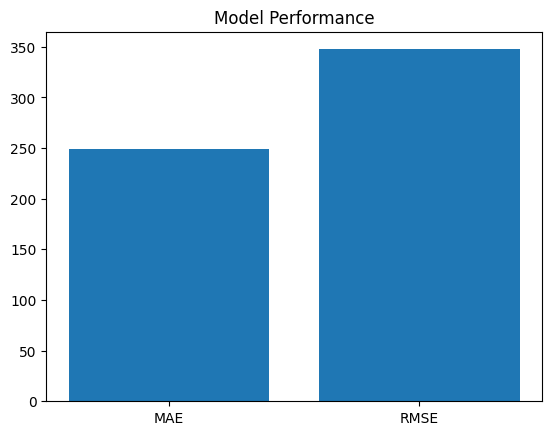

In [21]:
plt.figure()
plt.bar(["MAE", "RMSE"], [mae, rmse])
plt.title("Model Performance")
plt.show()

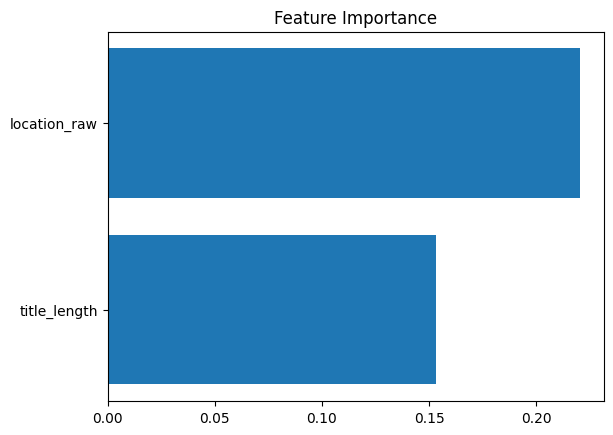

In [22]:
importance = permutation_importance(model, X_test, y_test)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importance.importances_mean
}).sort_values("importance", ascending=False)

importance_df.to_csv(f"results/importance/{run_id}.csv", index=False)

plt.figure()
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

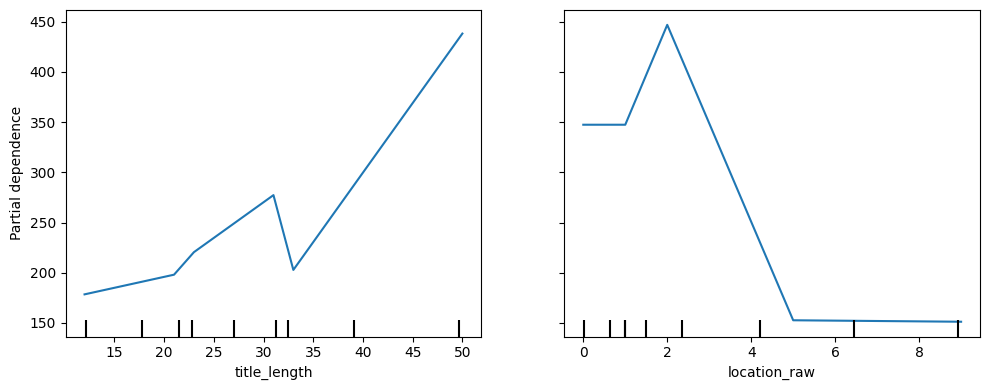

In [23]:
fig, ax = plt.subplots(figsize=(10,4))

PartialDependenceDisplay.from_estimator(model, X_test, [0,1], ax=ax)

plt.tight_layout()
plt.savefig(f"results/pdp/{run_id}.png")
plt.show()

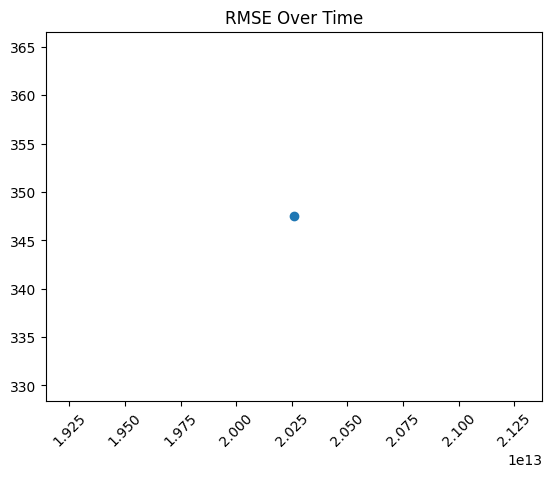

In [29]:
metrics_files = glob.glob("results/metrics_history/*.csv")

metrics_df = pd.concat([pd.read_csv(f) for f in metrics_files])
metrics_df = metrics_df.sort_values("run_id")

# RMSE
plt.figure()
plt.plot(metrics_df["run_id"], metrics_df["RMSE"], marker='o')
plt.xticks(rotation=45)
plt.title("RMSE Over Time")
plt.show()


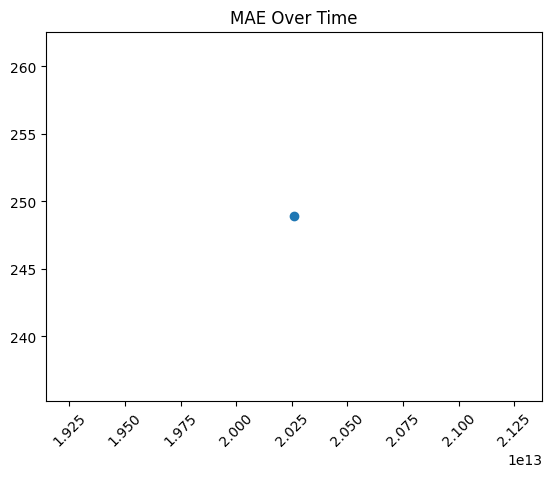

In [30]:
# MAE
plt.figure()
plt.plot(metrics_df["run_id"], metrics_df["MAE"], marker='o')
plt.xticks(rotation=45)
plt.title("MAE Over Time")
plt.show()

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

In [33]:
df = pd.read_csv("results/furniture_master.csv")

# Clean price
df["price"] = df["price_raw"].replace('[\$,]', '', regex=True).astype(float)

df = df.dropna(subset=["price"])

<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_1252/3737651606.py:4: SyntaxWarning: invalid escape sequence '\$'
  df["price"] = df["price_raw"].replace('[\$,]', '', regex=True).astype(float)


In [34]:
# Convert categorical to numeric
df["title_len"] = df["title"].astype(str).apply(len)
df["location_len"] = df["location_raw"].astype(str).apply(len)

features = ["title_len", "location_len"]

X = df[features]
y = df["price"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=None
)

model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [36]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 384.67553374738213
MAE: 272.9626666666666


In [37]:
run_id = datetime.now().strftime("%Y%m%d%H%M%S")

os.makedirs("results/metrics_history", exist_ok=True)

pd.DataFrame({
    "run_id": [run_id],
    "RMSE": [rmse],
    "MAE": [mae]
}).to_csv(f"results/metrics_history/{run_id}.csv", index=False)

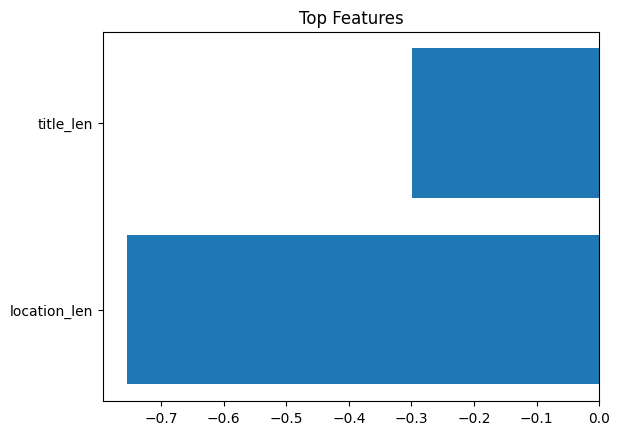

In [38]:
os.makedirs("results/importance", exist_ok=True)

perm = permutation_importance(model, X_test, y_test, n_repeats=5)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

importance_df.to_csv(f"results/importance/{run_id}.csv", index=False)

plt.figure()
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.savefig("results/importance/feature_importance.png")
plt.show()

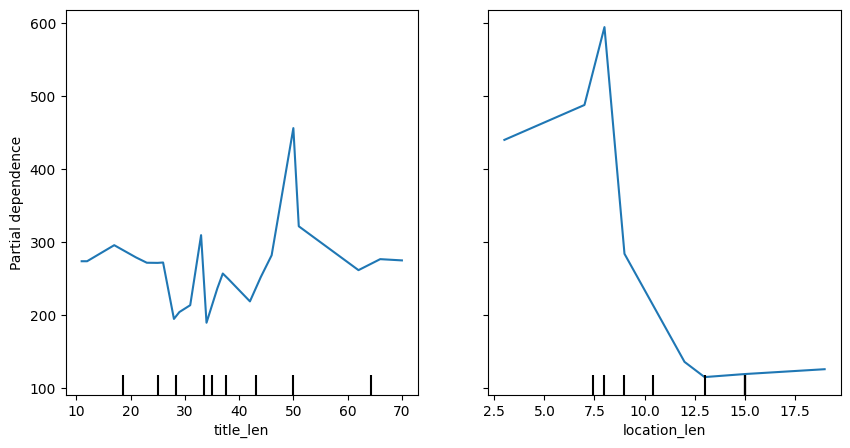

In [39]:
os.makedirs("results/pdp", exist_ok=True)

fig, ax = plt.subplots(figsize=(10,5))
PartialDependenceDisplay.from_estimator(model, X, features, ax=ax)

plt.savefig(f"results/pdp/{run_id}.png")
plt.show()

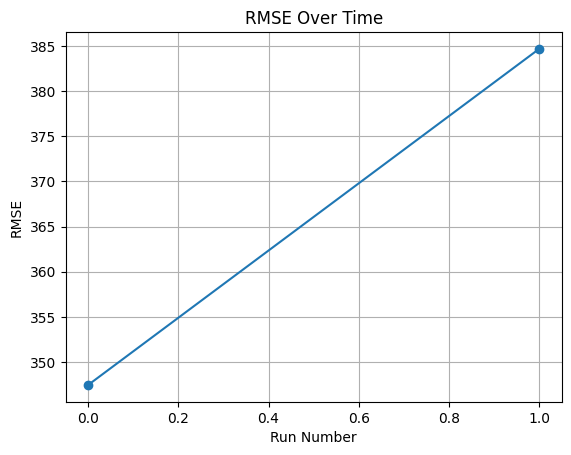

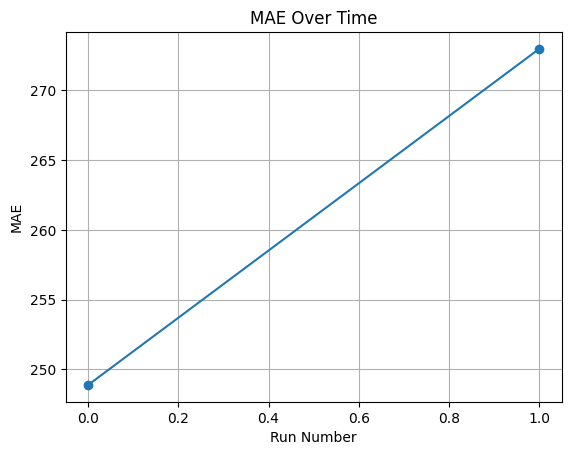

In [40]:
files = sorted(glob.glob("results/metrics_history/*.csv"))

dfs = [pd.read_csv(f) for f in files]
metrics_df = pd.concat(dfs, ignore_index=True)

# RMSE
plt.figure()
plt.plot(range(len(metrics_df)), metrics_df["RMSE"], marker='o')
plt.title("RMSE Over Time")
plt.xlabel("Run Number")
plt.ylabel("RMSE")
plt.grid()
plt.show()

# MAE
plt.figure()
plt.plot(range(len(metrics_df)), metrics_df["MAE"], marker='o')
plt.title("MAE Over Time")
plt.xlabel("Run Number")
plt.ylabel("MAE")
plt.grid()
plt.show()

In [41]:
from sklearn.inspection import permutation_importance
import os
import pandas as pd
import matplotlib.pyplot as plt

# Create folder
os.makedirs("results/importance", exist_ok=True)

# Calculate importance
perm = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42)

# Create dataframe
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean
})

# Sort
importance_df = importance_df.sort_values("importance", ascending=False)

# Save CSV
importance_df.to_csv(f"results/importance/{run_id}.csv", index=False)

print("Feature importance CSV saved ✅")

Feature importance CSV saved ✅


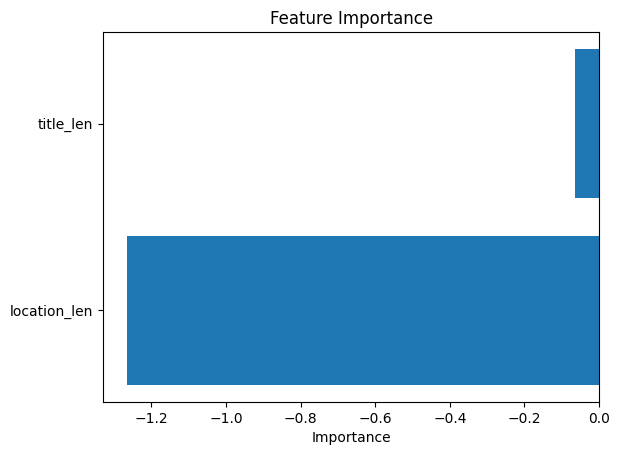

Feature importance PNG saved ✅


In [42]:
plt.figure()
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")

# Save image
plt.savefig("results/importance/feature_importance.png")

plt.show()

print("Feature importance PNG saved ✅")

In [43]:
!git clone https://github.com/OPIM5512-prb23017/craigslist-furniture-price-model.git
%cd craigslist-furniture-price-model

Cloning into 'craigslist-furniture-price-model'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 121 (delta 31), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (121/121), 41.83 KiB | 3.80 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/craigslist-furniture-price-model/craigslist-furniture-price-model/craigslist-furniture-price-model


In [44]:
import pandas as pd

df = pd.read_csv("results/furniture_master.csv")

In [45]:
df["price"] = df["price_raw"].replace(r'[\$,]', '', regex=True).astype(float)

df["title_len"] = df["title"].astype(str).apply(len)
df["location_len"] = df["location_raw"].astype(str).apply(len)

X = df[["title_len", "location_len"]]
y = df["price"]

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

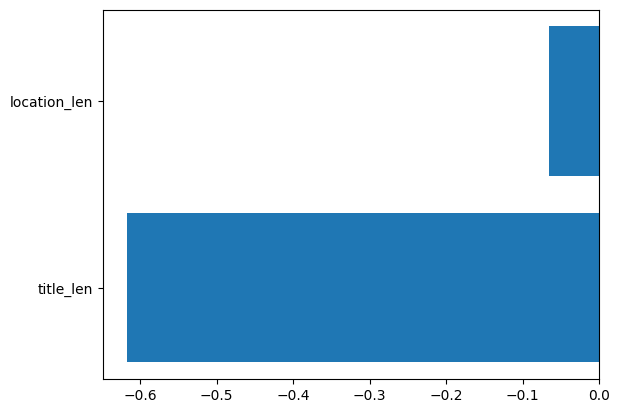

DONE


In [47]:
from sklearn.inspection import permutation_importance
import os
import matplotlib.pyplot as plt

os.makedirs("results/importance", exist_ok=True)

perm = permutation_importance(model, X_test, y_test)

import pandas as pd

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean
})

importance_df = importance_df.sort_values("importance", ascending=False)

importance_df.to_csv("results/importance/importance.csv", index=False)

plt.figure()
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.savefig("results/importance/feature_importance.png")
plt.show()

print("DONE")

In [48]:
!ls results/importance

feature_importance.png	importance.csv


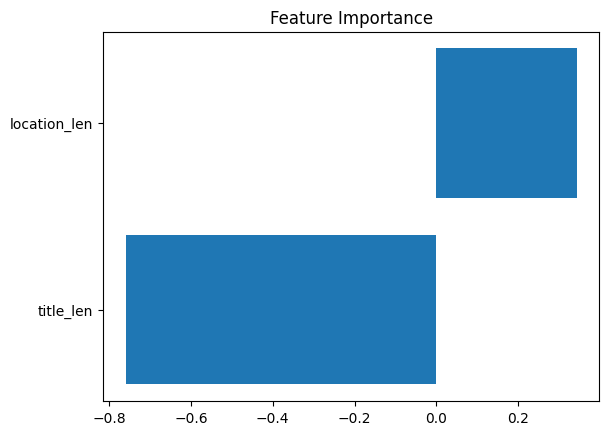

✅ CSV + PNG created


In [49]:
import os
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import pandas as pd

# Create folder
os.makedirs("results/importance", exist_ok=True)

# Calculate importance again
perm = permutation_importance(model, X_test, y_test, n_repeats=5)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

# Save CSV (overwrite ok)
importance_df.to_csv("results/importance/importance.csv", index=False)

# 🔥 THIS IS THE MISSING PART (PNG SAVE)
plt.figure()
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")

plt.savefig("results/importance/feature_importance.png")   # ⭐ IMPORTANT LINE
plt.show()

print("✅ CSV + PNG created")

In [50]:
!ls results/importance

feature_importance.png	importance.csv


In [51]:
for i in range(5):   # run 5 times
    print(f"Run {i+1}")

    run_id = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2
    )

    model = RandomForestRegressor(n_estimators=100)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # SAVE METRICS
    pd.DataFrame({
        "run_id":[run_id],
        "MAE":[mae],
        "RMSE":[rmse]
    }).to_csv(f"results/metrics_history/{run_id}.csv", index=False)

    # SAVE PREDICTIONS
    pd.DataFrame({
        "actual":y_test,
        "predicted":y_pred
    }).to_csv(f"results/predictions/{run_id}-preds.csv", index=False)

    # FEATURE IMPORTANCE
    perm = permutation_importance(model, X_test, y_test)
    imp_df = pd.DataFrame({
        "feature":X.columns,
        "importance":perm.importances_mean
    }).sort_values("importance", ascending=False)

    imp_df.to_csv(f"results/importance/{run_id}-importance.csv", index=False)

    plt.figure()
    plt.barh(imp_df["feature"], imp_df["importance"])
    plt.gca().invert_yaxis()
    plt.savefig(f"results/importance/{run_id}-importance.png")
    plt.close()

    # PDP
    fig, ax = plt.subplots(figsize=(8,4))
    PartialDependenceDisplay.from_estimator(model, X_test, [0,1], ax=ax)
    plt.savefig(f"results/pdp/{run_id}-pdp.png")
    plt.close()

Run 1


/tmp/ipykernel_1252/1147350572.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_id = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")


Run 2


/tmp/ipykernel_1252/1147350572.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_id = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")


Run 3


/tmp/ipykernel_1252/1147350572.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_id = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")


Run 4


/tmp/ipykernel_1252/1147350572.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_id = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")


Run 5


/tmp/ipykernel_1252/1147350572.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_id = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")


In [52]:
import os
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# folders
os.makedirs("results/metrics_history", exist_ok=True)
os.makedirs("results/importance", exist_ok=True)
os.makedirs("results/pdp", exist_ok=True)
os.makedirs("results/predictions", exist_ok=True)

# load
df = pd.read_csv("results/furniture_master.csv")

df["price"] = df["price_raw"].replace(r'[\$,]', '', regex=True).astype(float)
df["title_len"] = df["title"].astype(str).apply(len)
df["location_len"] = df["location_raw"].astype(str).apply(len)

X = df[["title_len", "location_len"]]
y = df["price"]

# 🔥 RUN MULTIPLE TIMES
for i in range(8):
    run_id = datetime.utcnow().strftime("%Y%m%dT%H%M%S")

    X_train, X_test, y_train, y_test = train_test_split(X, y)

    model = RandomForestRegressor()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # metrics
    pd.DataFrame({
        "run_id":[run_id],
        "MAE":[mae],
        "RMSE":[rmse]
    }).to_csv(f"results/metrics_history/{run_id}.csv", index=False)

    # predictions
    pd.DataFrame({
        "actual":y_test,
        "predicted":y_pred
    }).to_csv(f"results/predictions/{run_id}-preds.csv", index=False)

    # importance
    perm = permutation_importance(model, X_test, y_test)
    imp_df = pd.DataFrame({
        "feature":X.columns,
        "importance":perm.importances_mean
    }).sort_values("importance", ascending=False)

    imp_df.to_csv(f"results/importance/{run_id}-importance.csv", index=False)

    plt.figure()
    plt.barh(imp_df["feature"], imp_df["importance"])
    plt.gca().invert_yaxis()
    plt.title("Feature Importance")
    plt.savefig(f"results/importance/{run_id}-importance.png")
    plt.close()

    # PDP
    fig, ax = plt.subplots()
    PartialDependenceDisplay.from_estimator(model, X_test, [0,1], ax=ax)
    plt.savefig(f"results/pdp/{run_id}-pdp.png")
    plt.close()

print("DONE ✅ MULTIPLE RUNS CREATED")

/tmp/ipykernel_1252/2980172276.py:30: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_id = datetime.utcnow().strftime("%Y%m%dT%H%M%S")
/tmp/ipykernel_1252/2980172276.py:30: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_id = datetime.utcnow().strftime("%Y%m%dT%H%M%S")
/tmp/ipykernel_1252/2980172276.py:30: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_id = datetime.utcnow().strftime("%Y%m%dT%H%M%S")
/tmp/ipykernel_1252/2980172276.py:30: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled

DONE ✅ MULTIPLE RUNS CREATED


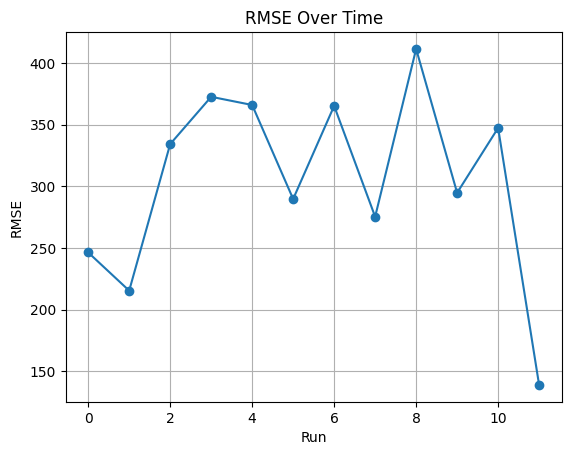

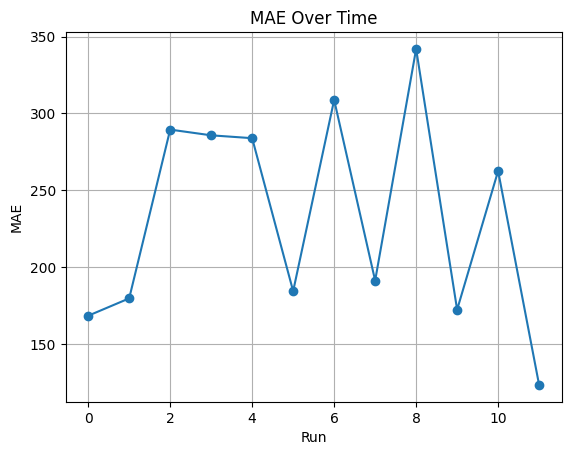

In [53]:
import glob

files = sorted(glob.glob("results/metrics_history/*.csv"))
df_list = [pd.read_csv(f) for f in files]
metrics_df = pd.concat(df_list)

# RMSE
plt.figure()
plt.plot(range(len(metrics_df)), metrics_df["RMSE"], marker='o')
plt.title("RMSE Over Time")
plt.xlabel("Run")
plt.ylabel("RMSE")
plt.grid()
plt.show()

# MAE
plt.figure()
plt.plot(range(len(metrics_df)), metrics_df["MAE"], marker='o')
plt.title("MAE Over Time")
plt.xlabel("Run")
plt.ylabel("MAE")
plt.grid()
plt.show()

In [54]:
!zip -r results.zip results

  adding: results/ (stored 0%)
  adding: results/raw_furniture_listings.csv (deflated 60%)
  adding: results/.gitkeep (stored 0%)
  adding: results/importance/ (stored 0%)
  adding: results/importance/20260407T015743-importance.csv (deflated 10%)
  adding: results/importance/.gitkeep (stored 0%)
  adding: results/importance/20260407T015741-importance.csv (deflated 10%)
  adding: results/importance/20260407T015742-importance.png (deflated 25%)
  adding: results/importance/20260407T015741-importance.png (deflated 26%)
  adding: results/importance/20260407T015136Z-importance.png (deflated 29%)
  adding: results/importance/20260407T015137Z-importance.png (deflated 33%)
  adding: results/importance/20260407T015736-importance.csv (deflated 9%)
  adding: results/importance/20260407T015737-importance.png (deflated 25%)
  adding: results/importance/20260407T015739-importance.csv (deflated 9%)
  adding: results/importance/20260407T015134Z-importance.csv (deflated 8%)
  adding: results/importance